# 00 Raw Behaviour EDA

Aim of this notebook: prepare the authentication event data for the static NHS analysis and perform the initial descriptive EDA.


## 0. Configuration

In [1]:
from pathlib import Path
import hashlib
import json

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from nhs_feature_utils import initialise_duckdb, write_parquet
import nhs_split_eval as se


# Raw authentication data and processed copy for faster reloading
AUTH_PATH = "auth.txt.gz"
AUTH_PARQUET = Path("auth_main.parquet")

# Analysis settings
ACCOUNT_SPLIT_PATH = Path("account_split_static.json")
ACCOUNT_SPLIT_META_PATH = Path("account_split_static_meta.json")

QUIET_HOURS_PATH = Path("quiet_hours.json")
QUIET_HOURS_META_PATH = Path("quiet_hours_meta.json")

WINDOW_DAYS = 14  # length of each analysis window
WIN = 0  # primary window used for descriptive EDA
MIN_AGG = 20  # minimum events required per account-window

SEED = 42
SPLIT_FRACS = (0.60, 0.15, 0.25)  # fit / calibration / test
N_QUIET_HOURS = 8  # number of low-activity hourly bins

# Reuse processed data unless rebuilding is requested
FORCE_AUTH_REBUILD = False

OUT = Path("eda_outputs_00_raw")
OUT.mkdir(exist_ok=True)

print("Configuration ready.")


Configuration ready.


## 1. Load authentication events

`initialise_duckdb` creates the working event view `e`, containing successful `LogOn` events within complete 14-day windows.


In [2]:
con, MAX_T, N_WIN = initialise_duckdb(
    auth_parquet=AUTH_PARQUET,
    auth_path=AUTH_PATH,
    window_days=WINDOW_DAYS,
    force_auth_rebuild=FORCE_AUTH_REBUILD,
)

event_scale = con.execute("""
SELECT
    COUNT(*) AS n_logon_events,
    COUNT(DISTINCT u) AS n_source_accounts
FROM e
""").df()

print(event_scale.to_string(index=False))
print(f"Complete windows: {N_WIN}")

Using existing auth_main.parquet
Success events: 1,038,590,151
Complete 14-day windows: 4
Discarded tail: 172799 seconds
DuckDB views restored: a, e


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

 n_logon_events  n_source_accounts
      444450050              54023
Complete windows: 4


## 2. Define eligible accounts and account split

Accounts with at least 20 successful `LogOn` events in one complete 14-day window are retained. Eligible accounts are split at account level into fitting, calibration and test partitions (60% / 15% / 25%).


In [3]:
# Eligible accounts: at least MIN_AGG events in one complete window
eligible = con.execute(f"""
SELECT DISTINCT u
FROM (
    SELECT
        u,
        win,
        COUNT(*) AS volume
    FROM e
    GROUP BY u, win
    HAVING COUNT(*) >= {MIN_AGG}
)
ORDER BY u
""").df()

eligible["u"] = eligible["u"].astype(str)
eligible_accounts = set(eligible["u"])

if not eligible_accounts:
    raise RuntimeError("No eligible accounts found.")

# Reuse the existing account split, or create it once
if ACCOUNT_SPLIT_PATH.exists():
    split_obj = json.loads(ACCOUNT_SPLIT_PATH.read_text())

    required_keys = {"fit", "calibration", "test"}
    if set(split_obj) != required_keys:
        raise KeyError(
            f"{ACCOUNT_SPLIT_PATH} must contain exactly {sorted(required_keys)}; "
            f"found {sorted(split_obj)}"
        )

    fit_a = set(map(str, split_obj["fit"]))
    cal_a = set(map(str, split_obj["calibration"]))
    te_a = set(map(str, split_obj["test"]))
    split_action = "reused existing split"
else:
    fit_a, cal_a, te_a = se.split_accounts(
        eligible,
        fracs=SPLIT_FRACS,
        seed=SEED,
    )
    fit_a = set(map(str, fit_a))
    cal_a = set(map(str, cal_a))
    te_a = set(map(str, te_a))

    se.save_account_split(
        ACCOUNT_SPLIT_PATH,
        fit_a,
        cal_a,
        te_a,
    )
    split_action = "created new split"

# Check that the partitions are disjoint and cover all eligible accounts
assert fit_a.isdisjoint(cal_a)
assert fit_a.isdisjoint(te_a)
assert cal_a.isdisjoint(te_a)

split_universe = fit_a | cal_a | te_a
missing_from_split = eligible_accounts - split_universe
extra_in_split = split_universe - eligible_accounts

if missing_from_split or extra_in_split:
    raise RuntimeError("Account split does not match the eligible-account universe.")

print(f"Eligible accounts : {len(eligible_accounts):,}")
print(f"Fit accounts      : {len(fit_a):,}")
print(f"Calibration       : {len(cal_a):,}")
print(f"Test              : {len(te_a):,}")
print(f"Split action      : {split_action}")

# Save reproducibility metadata
def account_set_hash(accounts):
    payload = "\n".join(sorted(map(str, accounts))).encode("utf-8")
    return hashlib.sha256(payload).hexdigest()

split_meta = {
    "pipeline_stage": "00_raw_behaviour_eda",
    "seed": SEED,
    "fractions": {
        "fit": SPLIT_FRACS[0],
        "calibration": SPLIT_FRACS[1],
        "test": SPLIT_FRACS[2],
    },
    "window_days": WINDOW_DAYS,
    "min_agg": MIN_AGG,
    "n_complete_windows": N_WIN,
    "eligibility_rule": (
        "Account has >= MIN_AGG successful LogOn events in at least one "
        "complete 14-day account-window."
    ),
    "event_stream": "Success + LogOn, source-account ownership",
    "n_eligible_accounts": len(eligible_accounts),
    "n_fit_accounts": len(fit_a),
    "n_calibration_accounts": len(cal_a),
    "n_test_accounts": len(te_a),
    "eligible_account_sha256": account_set_hash(eligible_accounts),
    "fit_account_sha256": account_set_hash(fit_a),
    "calibration_account_sha256": account_set_hash(cal_a),
    "test_account_sha256": account_set_hash(te_a),
}

ACCOUNT_SPLIT_META_PATH.write_text(json.dumps(split_meta, indent=2))


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Eligible accounts : 29,558
Fit accounts      : 17,734
Calibration       : 4,433
Test              : 7,391
Split action      : reused existing split


890

## 3. Define weak account-type proxies

Account names are used as weak descriptive proxies. Dollar-suffix accounts form the machine proxy, U-prefixed accounts the user proxy, and `SYSTEM`, `LOCAL SERVICE` and `NETWORK SERVICE` the named-system reference. `ANONYMOUS LOGON` is kept separate.

For broad descriptive comparisons, the machine-proxy and named-system groups are combined as the `automation-associated reference`.


In [4]:
# Weak account-name proxy definitions
SYSTEM_REFERENCE_NAMES = [
    "SYSTEM",
    "LOCAL SERVICE",
    "NETWORK SERVICE",
]
ANONYMOUS_NAME = "ANONYMOUS LOGON"

ACCOUNT_TYPE_ORDER = [
    "U-named user proxy",
    "$ machine proxy",
    "named system",
    "anonymous logon",
    "other",
]

BINARY_PROXY_ORDER = [
    "U-named user proxy",
    "automation-associated reference",
    "other",
]

def account_type(u):
    s = str(u).upper()
    if "$@" in s or s.endswith("$"):
        return "$ machine proxy"
    if ANONYMOUS_NAME in s:
        return "anonymous logon"
    if any(name in s for name in SYSTEM_REFERENCE_NAMES):
        return "named system"
    if s.startswith("U"):
        return "U-named user proxy"
    return "other"

def binary_proxy_from_account_type(x):
    if x == "U-named user proxy":
        return "U-named user proxy"
    if x in {"$ machine proxy", "named system"}:
        return "automation-associated reference"
    return "other"

eligible_account_types = pd.DataFrame({"u": sorted(eligible_accounts)})
eligible_account_types["account_type"] = eligible_account_types["u"].map(account_type)
eligible_account_types["binary_proxy"] = eligible_account_types["account_type"].map(
    binary_proxy_from_account_type
)

binary_counts = (
    eligible_account_types.groupby("binary_proxy", as_index=False)
    .agg(n_accounts=("u", "nunique"))
)

subtype_counts = (
    eligible_account_types.groupby(["binary_proxy", "account_type"], as_index=False)
    .agg(n_accounts=("u", "nunique"))
)

print("=== FULL ELIGIBLE POPULATION: binary proxy counts ===")
print(
    binary_counts.set_index("binary_proxy")
    .reindex(BINARY_PROXY_ORDER)
    .dropna(how="all")
    .to_string()
)

print("\n=== FULL ELIGIBLE POPULATION: diagnostic subtype counts ===")
print(
    subtype_counts.sort_values(["binary_proxy", "n_accounts"], ascending=[True, False])
    .to_string(index=False)
)

binary_counts.to_csv(OUT / "00_full_binary_proxy_counts.csv", index=False)
subtype_counts.to_csv(OUT / "00_full_account_type_subtype_counts.csv", index=False)


=== FULL ELIGIBLE POPULATION: binary proxy counts ===
                                 n_accounts
binary_proxy                               
U-named user proxy                    10101
automation-associated reference       18215
other                                  1242

=== FULL ELIGIBLE POPULATION: diagnostic subtype counts ===
                   binary_proxy       account_type  n_accounts
             U-named user proxy U-named user proxy       10101
automation-associated reference    $ machine proxy       13538
automation-associated reference       named system        4677
                          other    anonymous logon        1242


## 4. Define enterprise-wide quiet hours

LANL timestamps are relative. The eight relative hour-of-day bins with the lowest aggregate successful `LogOn` volume across the complete event stream are used as enterprise-wide quiet hours and saved for downstream calculation of `quiet_frac`.


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

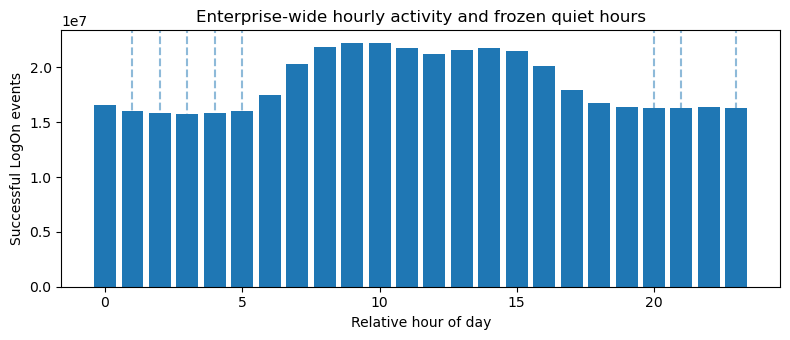

Enterprise-wide quiet hours: [1, 2, 3, 4, 5, 20, 21, 23]
Saved: quiet_hours.json
Saved provenance: quiet_hours_meta.json


In [5]:
# Enterprise-wide hourly activity and quiet-hour definition
hourly_global = con.execute("""
SELECT
    CAST((t % 86400) // 3600 AS INT) AS hour,
    COUNT(*) AS n
FROM e
GROUP BY hour
ORDER BY hour
""").df()

hourly_global = (
    hourly_global.set_index("hour")
    .reindex(range(24), fill_value=0)
    .rename_axis("hour")
    .reset_index()
)

quiet_hours = (
    hourly_global.sort_values(["n", "hour"])
    .head(N_QUIET_HOURS)["hour"]
    .astype(int)
    .sort_values()
    .tolist()
)

if len(quiet_hours) != N_QUIET_HOURS:
    raise RuntimeError(
        f"Expected {N_QUIET_HOURS} quiet hours, got {len(quiet_hours)}."
    )

QUIET_HOURS_PATH.write_text(json.dumps(quiet_hours, indent=2))

quiet_meta = {
    "scope": "enterprise_wide",
    "time_scope": "all_complete_windows",
    "window_days": WINDOW_DAYS,
    "n_hours": N_QUIET_HOURS,
    "quiet_hours": quiet_hours,
    "definition": (
        "Eight relative hour-of-day bins with the lowest aggregate successful "
        "LogOn event volume across the complete enterprise event stream."
    ),
    "uses_account_labels": False,
}
QUIET_HOURS_META_PATH.write_text(json.dumps(quiet_meta, indent=2))

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.bar(hourly_global["hour"], hourly_global["n"])
for h in quiet_hours:
    ax.axvline(h, linestyle="--", alpha=0.5)
ax.set_xlabel("Relative hour of day")
ax.set_ylabel("Successful LogOn events")
ax.set_title("Enterprise-wide hourly activity and frozen quiet hours")
plt.tight_layout()
plt.savefig(OUT / "01_global_hourly_activity_and_quiet_hours.png", dpi=200)
plt.show()

hourly_global.to_csv(OUT / "01_global_hourly_activity.csv", index=False)

print("Enterprise-wide quiet hours:", quiet_hours)
print("Saved:", QUIET_HOURS_PATH)
print("Saved provenance:", QUIET_HOURS_META_PATH)


## 5. Compute window-0 descriptive summaries

For each eligible account in window 0, compute activity volume, destination fanout, active days, quiet-hour fraction and inter-arrival-time CV.


In [6]:
quiet_list = ",".join(map(str, quiet_hours))

eda_stats = con.execute(f"""
WITH base AS (
    SELECT
        e.u,
        COUNT(*) AS volume,
        COUNT(DISTINCT e.dst_comp) AS fanout,
        COUNT(DISTINCT e.t // 86400) AS active_days,
        AVG(
            CASE
                WHEN CAST((e.t % 86400) // 3600 AS INT) IN ({quiet_list})
                THEN 1.0 ELSE 0.0
            END
        ) AS quiet_frac
    FROM e
    WHERE e.win = {WIN}
    GROUP BY e.u
    HAVING COUNT(*) >= {MIN_AGG}
),
gaps AS (
    SELECT
        e.u,
        e.t - LAG(e.t) OVER (PARTITION BY e.u ORDER BY e.t) AS gap
    FROM e
    WHERE e.win = {WIN}
),
cv AS (
    SELECT
        u,
        STDDEV_POP(gap) / NULLIF(AVG(gap), 0) AS iat_cv
    FROM gaps
    WHERE gap IS NOT NULL
    GROUP BY u
)
SELECT
    base.*,
    cv.iat_cv
FROM base
LEFT JOIN cv USING (u)
ORDER BY u
""").df()

eda_stats["u"] = eda_stats["u"].astype(str)
eda_stats["account_type"] = eda_stats["u"].map(account_type)
eda_stats["binary_proxy"] = eda_stats["account_type"].map(
    binary_proxy_from_account_type
)

eda_stats["log_volume"] = np.log10(eda_stats["volume"].clip(lower=1))
eda_stats["log_fanout"] = np.log10(eda_stats["fanout"].clip(lower=0) + 1)

if not set(eda_stats["u"]).issubset(eligible_accounts):
    raise RuntimeError("EDA table contains an account outside the frozen eligible universe.")

print(f"Window-0 EDA accounts: {eda_stats['u'].nunique():,}")

write_parquet(
    con,
    eda_stats,
    OUT / "02_full_raw_eda_account_stats_win0.parquet",
    temp_name="_eda_stats_00",
)

eda_stats.to_csv(
    OUT / "02_full_raw_eda_account_stats_win0.csv",
    index=False
)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Window-0 EDA accounts: 26,120


## 6. Descriptive account-group comparisons

First compare the U-named user proxy with the broader automation-associated reference. Then separate dollar-suffix computer accounts and named system accounts to show behavioural heterogeneity within the automation-associated group.


In [7]:
MAIN_FEATURES = [
    "log_volume",
    "log_fanout",
    "active_days",
    "quiet_frac",
    "iat_cv",
]

main_eda = eda_stats[
    eda_stats["binary_proxy"].isin(
        ["U-named user proxy", "automation-associated reference"]
    )
].copy()

def grouped_numeric_summary(df, group_col, features):
    rows = []
    for group, sub in df.groupby(group_col):
        row = {
            group_col: group,
            "n_accounts": sub["u"].nunique(),
        }
        for col in features:
            x = sub[col].dropna()
            row[f"{col}_median"] = x.median()
            row[f"{col}_q25"] = x.quantile(0.25)
            row[f"{col}_q75"] = x.quantile(0.75)
        rows.append(row)
    return pd.DataFrame(rows)

binary_summary = grouped_numeric_summary(
    main_eda,
    "binary_proxy",
    MAIN_FEATURES,
)

print(binary_summary.to_string(index=False))
binary_summary.to_csv(OUT / "03_full_binary_population_summary.csv", index=False)


                   binary_proxy  n_accounts  log_volume_median  log_volume_q25  log_volume_q75  log_fanout_median  log_fanout_q25  log_fanout_q75  active_days_median  active_days_q25  active_days_q75  quiet_frac_median  quiet_frac_q25  quiet_frac_q75  iat_cv_median  iat_cv_q25  iat_cv_q75
             U-named user proxy        9334           3.146748        2.795358        3.365441           1.113943        1.041393        1.176091                10.0              8.0             14.0           0.208262        0.021889        0.287505       6.080418    2.552201   10.371096
automation-associated reference       16049           3.496376        2.693727        3.681060           1.146128        0.301030        1.176091                14.0              9.0             14.0           0.287846        0.216495        0.315252       1.533011    1.302530    7.981320


### Three-group descriptive comparison

Compare the U-named user proxy, dollar-suffix computer accounts and named system accounts separately.


In [8]:
diagnostic = eda_stats[
    eda_stats["account_type"].isin(
        ["U-named user proxy", "$ machine proxy", "named system"]
    )
].copy()

subtype_summary = grouped_numeric_summary(
    diagnostic,
    "account_type",
    MAIN_FEATURES,
)

print(subtype_summary.to_string(index=False))
subtype_summary.to_csv(OUT / "04_full_subtype_population_summary.csv", index=False)


      account_type  n_accounts  log_volume_median  log_volume_q25  log_volume_q75  log_fanout_median  log_fanout_q25  log_fanout_q75  active_days_median  active_days_q25  active_days_q75  quiet_frac_median  quiet_frac_q25  quiet_frac_q75  iat_cv_median  iat_cv_q25  iat_cv_q75
   $ machine proxy       12018           3.617996        3.388678        3.711217           1.146128        1.113943        1.176091                14.0              9.0             14.0           0.297325        0.239002        0.319319       1.719937    1.369113   12.878303
U-named user proxy        9334           3.146748        2.795358        3.365441           1.113943        1.041393        1.176091                10.0              8.0             14.0           0.208262        0.021889        0.287505       6.080418    2.552201   10.371096
      named system        4031           2.503791        2.344392        2.645422           0.301030        0.301030        0.301030                14.0              9.0

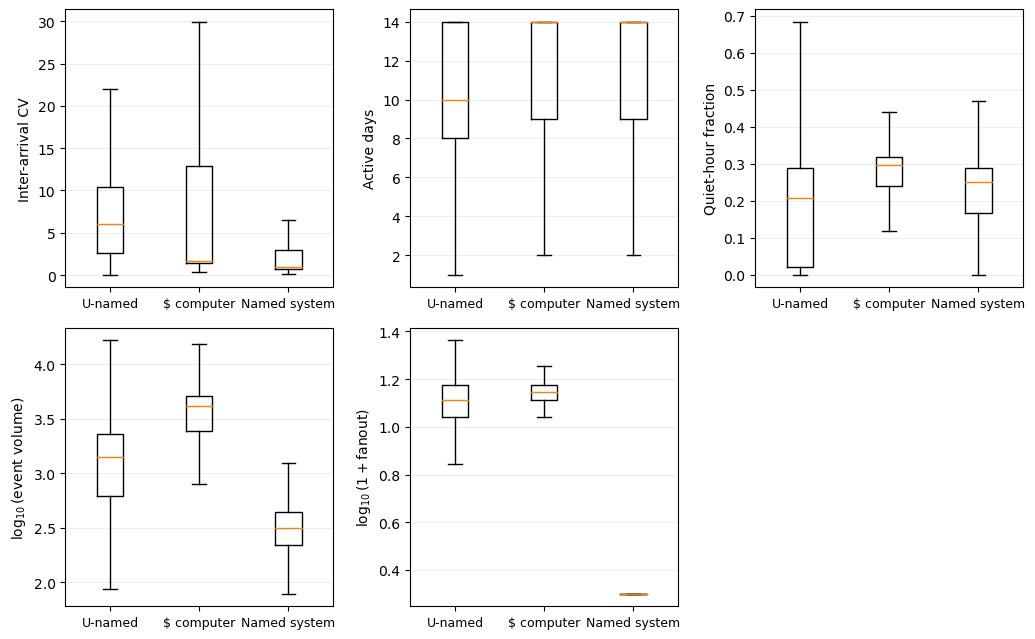

In [9]:
# Figure 1: three-group descriptive behavioural comparison

plot_groups = [
    "U-named user proxy",
    "$ machine proxy",
    "named system",
]

group_labels = [
    "U-named",
    "$ computer",
    "Named system",
]

plot_features = [
    ("iat_cv", "Inter-arrival CV"),
    ("active_days", "Active days"),
    ("quiet_frac", "Quiet-hour fraction"),
    ("log_volume", r"$\log_{10}$(event volume)"),
    ("log_fanout", r"$\log_{10}(1+\mathrm{fanout})$"),
]

fig, axes = plt.subplots(2, 3, figsize=(10.5, 6.5))
axes = axes.ravel()

for ax, (col, ylabel) in zip(axes, plot_features):
    values = [
        diagnostic.loc[
            diagnostic["account_type"] == group, col
        ].dropna().to_numpy()
        for group in plot_groups
    ]

    ax.boxplot(
        values,
        labels=group_labels,
        showfliers=False,
    )

    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", labelsize=9)
    ax.grid(axis="y", alpha=0.2)

axes[-1].axis("off")

plt.tight_layout()

out_path = OUT / "Figure_01_three_group_behaviour_boxplots.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

## 7. Relative hour-of-day profiles

Compare relative hourly activity across weak account groups. Dashed lines mark the enterprise-wide quiet hours. These plots are retained as descriptive diagnostics and are not used for model fitting.


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

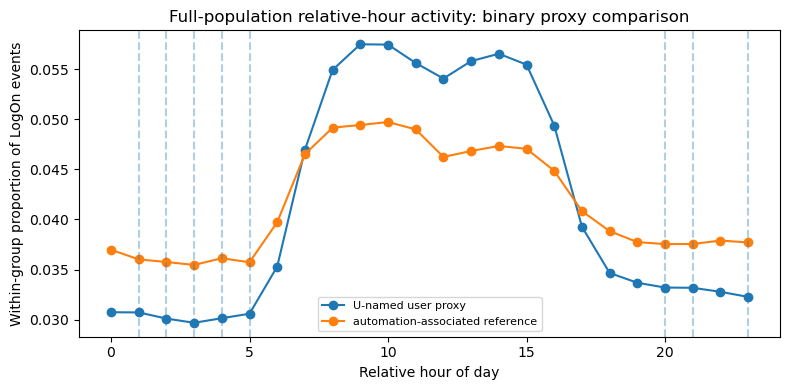

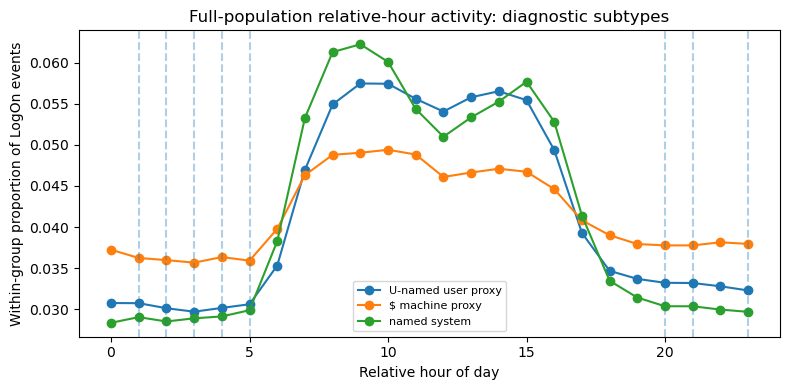

In [10]:
hourly_user = con.execute(f"""
SELECT
    e.u,
    CAST((e.t % 86400) // 3600 AS INT) AS hour,
    COUNT(*) AS n
FROM e
WHERE e.win = {WIN}
GROUP BY e.u, hour
ORDER BY e.u, hour
""").df()

hourly_user["u"] = hourly_user["u"].astype(str)
hourly_user["account_type"] = hourly_user["u"].map(account_type)
hourly_user["binary_proxy"] = hourly_user["account_type"].map(
    binary_proxy_from_account_type
)

def plot_hourly_profile(df, group_col, order, out_path, title):
    grouped = (
        df.groupby([group_col, "hour"], as_index=False)["n"]
        .sum()
    )
    grouped["prop"] = grouped.groupby(group_col)["n"].transform(
        lambda x: x / x.sum()
    )

    fig, ax = plt.subplots(figsize=(8, 4))
    for group in order:
        sub = grouped[grouped[group_col] == group]
        if sub.empty:
            continue
        full = (
            sub.set_index("hour")["prop"]
            .reindex(range(24), fill_value=0)
        )
        ax.plot(full.index, full.values, marker="o", label=group)

    for h in quiet_hours:
        ax.axvline(h, linestyle="--", alpha=0.35)

    ax.set_xlabel("Relative hour of day")
    ax.set_ylabel("Within-group proportion of LogOn events")
    ax.set_title(title)
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(out_path, dpi=200)
    plt.show()

plot_hourly_profile(
    hourly_user[
        hourly_user["binary_proxy"].isin(
            ["U-named user proxy", "automation-associated reference"]
        )
    ],
    "binary_proxy",
    ["U-named user proxy", "automation-associated reference"],
    OUT / "05_full_binary_hourly_profiles.png",
    "Full-population relative-hour activity: binary proxy comparison",
)

plot_hourly_profile(
    hourly_user[
        hourly_user["account_type"].isin(
            ["U-named user proxy", "$ machine proxy", "named system"]
        )
    ],
    "account_type",
    ["U-named user proxy", "$ machine proxy", "named system"],
    OUT / "05_full_subtype_hourly_profiles.png",
    "Full-population relative-hour activity: diagnostic subtypes",
)

hourly_user.to_csv(OUT / "05_full_hourly_activity_by_account.csv", index=False)


## 8. Reproducibility checks


In [11]:
# Account split
assert fit_a.isdisjoint(cal_a)
assert fit_a.isdisjoint(te_a)
assert cal_a.isdisjoint(te_a)
assert (fit_a | cal_a | te_a) == eligible_accounts

# Descriptive EDA population
assert set(eda_stats["u"]).issubset(eligible_accounts)

# Quiet-hour definition
saved_quiet = json.loads(QUIET_HOURS_PATH.read_text())
saved_quiet_meta = json.loads(QUIET_HOURS_META_PATH.read_text())

assert saved_quiet == quiet_hours
assert saved_quiet_meta["scope"] == "enterprise_wide"
assert saved_quiet_meta["time_scope"] == "all_complete_windows"
assert saved_quiet_meta["uses_account_labels"] is False

print("Reproducibility checks passed.")


Reproducibility checks passed.
